In [1]:
import os
import sys
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings("ignore")
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [2]:
from pathlib import Path
import sys
_cwd = Path.cwd().resolve()
for _p in [_cwd, *_cwd.parents]:
    if (_p / 'python' / 'src').exists():
        sys.path.insert(0, str(_p / 'python' / 'src'))
        break
from deep_hashing_models import *
from similarities import *
from lsh_search import *

# 1. Data Preparation

In [3]:
data_repo = os.path.join(os.path.dirname(os.path.dirname(os.path.dirname(os.getcwd()))),'data/')

In [4]:
df_distinct_stacks = pd.read_csv(data_repo + 'frequent_stack_traces.csv', index_col = [0])
df_measures = pd.read_csv(data_repo + 'similarity-measures-pairs.csv', index_col = [0])

In [5]:
n_stacks = df_distinct_stacks.shape[0]
n_stacks

1000

In [6]:
vectorizer_bag_of_frames = CountVectorizer(token_pattern = r"(?u)\b[a-zA-Z0-9_.]{2,}\b")
s = df_distinct_stacks['stackTraceCusto'].apply(lambda x : x.replace('\n',' '))
s = s.apply(lambda x : x.replace('$',''))
s = s.apply(lambda x : x.replace('/',''))
s = s.apply(lambda x : x.replace('<',''))
s = s.apply(lambda x : x.replace('>',''))
X_bag_of_frames = vectorizer_bag_of_frames.fit_transform(list(s)).toarray()
df_bag_of_frames = pd.DataFrame(data = X_bag_of_frames, columns = vectorizer_bag_of_frames.get_feature_names())

In [7]:
X_train, X_validation, Y_train, Y_validation = train_test_split(df_measures.index, df_measures['Jaccard'], test_size = 0.2) 

In [8]:
indexes_train_1 = X_train.to_series().apply(lambda x : get_two_indexes(x, df_distinct_stacks.shape[0])[0]).to_list()
indexes_train_2 = X_train.to_series().apply(lambda x : get_two_indexes(x, df_distinct_stacks.shape[0])[1]).to_list()
indexes_validation_1 = X_validation.to_series().apply(lambda x : get_two_indexes(x, df_distinct_stacks.shape[0])[0]).to_list()
indexes_validation_2 = X_validation.to_series().apply(lambda x : get_two_indexes(x, df_distinct_stacks.shape[0])[1]).to_list()

In [9]:
X_train = dict()
X_train['stack_1'] = df_bag_of_frames.loc[indexes_train_1].values
X_train['stack_2'] = df_bag_of_frames.loc[indexes_train_2].values

X_validation = dict()
X_validation['stack_1'] = df_bag_of_frames.loc[indexes_validation_1].values
X_validation['stack_2'] = df_bag_of_frames.loc[indexes_validation_2].values

In [10]:
Y_train = Y_train.values
Y_validation = Y_validation.values

In [11]:
assert X_train['stack_1'].shape == X_train['stack_2'].shape
assert len(X_train['stack_1']) == len(Y_train)

### Distribution of training data

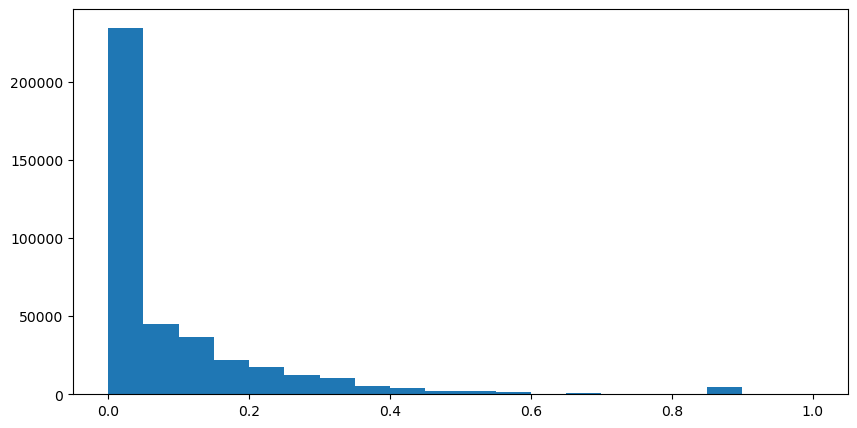

In [12]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.hist(Y_train, 20, alpha = 1, density = False)
plt.show()

### Distribution of test data

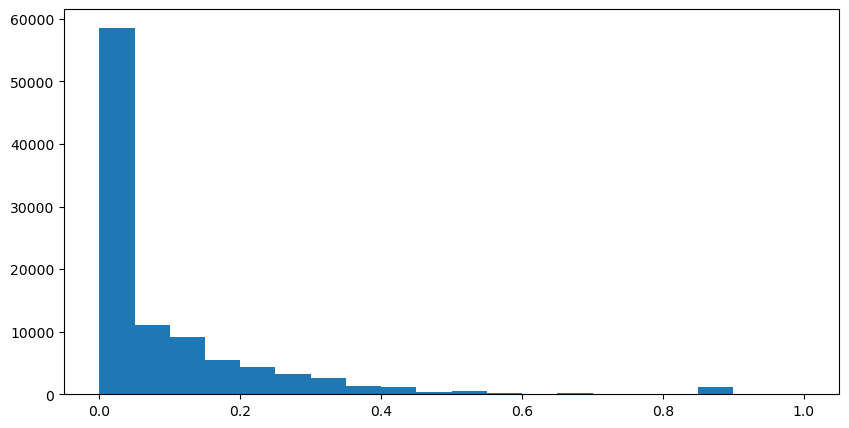

In [13]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.hist(Y_validation, 20, alpha = 1, density = False)
plt.show()

# 2. Model Design

In [14]:
'Number of hash tables functions' 
m = 64

In [15]:
'Number of bits per hash function' 
b = 16

In [16]:
'Size hash vector'
size_hash_vector = m * b
size_hash_vector

1024

## 2.1. Feature learning phase

In [17]:
x = Sequential()
x.add(Dense(2048, input_dim = X_train['stack_1'].shape[1], activation = 'sigmoid'))
x.add(Dense(1024, activation = 'sigmoid'))
x.add(Dense(size_hash_vector, activation = 'tanh'))
shared_model = x

## 2.2. Siamese Model 

In [18]:
input_shape = (X_train['stack_1'].shape[1],)
model = siamese_model_baseline(shared_model, input_shape, is_sparse = True, print_summary = True)

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 2272)]       0                                            
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 2272)]       0                                            
__________________________________________________________________________________________________
sequential (Sequential)         (None, 1024)         7802880     input_1[0][0]                    
                                                                 input_2[0][0]                    
                                                                 input_1[0][0]                    
                                                                 input_2[0][0]                

## 2.3. Model training 

In [ ]:
siamese_model = train_siamese_model_baseline(model, X_train, X_validation, Y_train, Y_validation, size_hash_vector, batch_size = 512, epochs = 20)

2026-04-06 17:44:54.017408: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2026-04-06 17:44:54.017563: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Epoch 1/20
499/781 [==================>...........] - ETA: 51s - loss: -0.4432 - manh_dist_loss: 0.0946 - abs_vect_loss: -0.9810 - abs_vect_1_loss: -0.9811 - manh_dist_rmse: 0.3076 - manh_dist_mae: 0.2072

# 3. Model Evaluation

In [ ]:
model.layers

## 3.1. Loss functions

#### 3.1.1. MSE of $\mathcal{L}_{Baseline}$

In [ ]:
plt.rcParams["figure.figsize"] = (4.5,4)
plt.plot(siamese_model.history['loss'], linewidth = 2.5)
plt.plot(siamese_model.history['val_loss'], linewidth = 2.5)
plt.title('Jaccard (CNNH+LSH)', fontsize = 18)
plt.ylabel('MSE (Model)', fontsize = 14)
plt.xlabel('Epochs', fontsize = 14)
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)
plt.ticklabel_format(style='', scilimits=(0,0))
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=15)
plt.savefig('Results/Baseline/loss-MSE.png', bbox_inches='tight')

#### 3.1.2. RMSE of Similarity preserving loss

In [ ]:
plt.rcParams["figure.figsize"] = (4.5,4)
plt.plot(siamese_model.history[model.layers[3].name + '_rmse'], linewidth = 2.5)
plt.plot(siamese_model.history['val_' + model.layers[3].name + '_rmse'], linewidth = 2.5)
plt.title('Jaccard (CNNH+LSH)', fontsize = 18)
plt.ylabel('RMSE (LSH-preserving)', fontsize = 14)
plt.xlabel('Epochs', fontsize = 14)
plt.xticks(fontsize= 12)
plt.yticks(fontsize= 12)
plt.ticklabel_format(style='', scilimits=(0,0))
plt.savefig('Results/Baseline/loss-LSH-preserving.png', bbox_inches='tight')
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=15)

#### 3.1.3. MAE of LSH preserving loss

In [ ]:
plt.rcParams["figure.figsize"] = (4.5,4)
plt.plot(siamese_model.history[model.layers[3].name + '_mae'], linewidth = 2.5)
plt.plot(siamese_model.history['val_' + model.layers[3].name + '_mae'], linewidth = 2.5)
plt.title('Jaccard (CNNH+LSH)', fontsize = 18)
plt.ylabel('MAE (LSH-preserving)', fontsize = 14)
plt.xlabel('Epochs', fontsize = 14)
plt.ticklabel_format(style='', scilimits=(0,0))
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=15)

## 3.2. Model Predictions

In [ ]:
predictions = predict(model, X_validation)

### 3.2.1. Examples

In [ ]:
np.around(predictions[0][:50],3) 

In [ ]:
np.around(Y_validation[:50],3) 

### 3.2.2. Spearman $\rho$ and Kendall $\tau$ correlation

In [ ]:
plt.rcParams["figure.figsize"] = (4,4)
plt.scatter(Y_validation, predictions[0], alpha = 0.5, marker = 'x', c = '#227093')
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.xlabel("Jaccard similarity values", fontsize = 12)
plt.ylabel("Collision probability", fontsize = 12)
plt.savefig('Results/Baseline/Jaccard-correlation', bbox_inches='tight')
plt.show()

In [ ]:
rho, p_value = spearman_rho(predictions, Y_validation)
rho

In [ ]:
tau, p_value = kendall_tau(predictions, Y_validation)
tau

## 3.3. Approximate Hamming Evaluation

In [ ]:
output_layer = 2
model.layers[output_layer]

In [ ]:
intermediate_model = intermediate_model_trained(shared_model, output_layer)

In [ ]:
intermediate_model.save('Models/model-baseline.model')

In [ ]:
#intermediate_model = keras.models.load_model('Models/model-baseline.model')

### 3.3.1. Example of a hash vector provided by the model (in the last epoch)

In [ ]:
'First 64 bits'
intermediate_model.predict(df_bag_of_frames.iloc[[10]])[0][:64]

### 3.3.2. Average value of the absolute hash values

In [ ]:
hash_vectors = intermediate_model.predict(df_bag_of_frames)

In [ ]:
np.mean(np.abs(hash_vectors))

### 3.3.3. Ratio of binary values from hash vectors provided by the model

In [ ]:
hash_vectors[(hash_vectors == 1) | (hash_vectors == -1)].size / hash_vectors.size

### 3.3.4. Comparison between approximate hamming and real hamming

In [ ]:
df_hamming = compare_hamming(X_validation, intermediate_model, b, size_hash_vector)

In [ ]:
df_hamming

In [ ]:
plt.rcParams["figure.figsize"] = (4,4)
plt.scatter(predictions[0], df_hamming['hamming'], alpha = 0.5, marker = 'x', c = '#b33939')
plt.xlabel("Distance between vectors", fontsize = 12)
plt.ylabel("Hamming Similarity", fontsize = 12)
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.savefig('Results/Baseline/Jaccard-hamming-comparison', bbox_inches='tight')
plt.show()

# 4. Locality Sensitive Hashing

In [ ]:
hash_vectors_hamming = convert_to_hamming(hash_vectors)

In [ ]:
params = lsh_hyperparams(m)
'(K,L)'
params 

## 4.1. Choose the best combination (L, K)

In [ ]:
plt.rcParams["figure.figsize"] = [9, 5]
x = np.linspace(0, 1, 100)
for param in params:
    y = 1 - (1 - (x)**param[1])**param[0]
    plt.plot(x, y, label = 'L = %d, r = %d' %param)
plt.xlabel("similarity values", fontsize = 12)
plt.ylabel("hash probability in at least 1 bucket", fontsize = 12)
plt.title('Probability-similarity relation', fontsize = 20)
plt.legend()

In [ ]:
df_probLSH = mean_prob_hashing_smallest_elt(n_stacks, params, hash_vectors_hamming, b, df_measures, 'Jaccard', trace = False)

In [ ]:
f, ax = plt.subplots(figsize=(4.5, 4))
ax = sns.boxplot(data = df_probLSH, palette="Set3")
plt.xlabel("Hyperparameters of LSH (L,K)", fontsize = 12)
plt.ylabel("Prob hashing smallest elt in buckets", fontsize = 12)
plt.title('Jaccard (CNNH+LSH) [Relation Prob-Sim]', fontsize = 16)
plt.savefig('Results/Baseline/Jaccard-Relation-Prob-Sim', bbox_inches='tight')
plt.show()

In [ ]:
'L = K = 8'
L, K = params[3]
L, K

### 4.1.1 Mean and Median probability for all stack traces for the best combination of $K$ and $L$

In [ ]:
df_probLSH.mean()['(8, 8)']

In [ ]:
df_probLSH.median()['(8, 8)']

## 4.2. Build hash tables with binary hash vectors w.r.t $K$ and $L$

In [ ]:
hash_tables = create_hash_tables(L, K, b, hash_vectors_hamming)

In [ ]:
with open('Hash-Tables/hash_tables_baseline.pkl', 'wb') as f:
    pickle.dump(hash_tables, f)

## 4.3. Search for approximate nearest neighbors (this procedure need to be explained in the paper) 

In [ ]:
'pointer to the stack trace'
index = random.randint(0,n_stacks)
index

In [ ]:
set_near_duplicates = near_duplicates(L, K, b, index, hash_vectors_hamming, hash_tables)
set_near_duplicates

In [ ]:
list_near_duplicate_pairs = near_duplicate_pairs(index, set_near_duplicates, n_stacks)
n_duplicate_pairs = len(list_near_duplicate_pairs)

In [ ]:
near_duplicates_sim = df_measures['Jaccard'][list_near_duplicate_pairs].sort_values(ascending = False)
near_duplicates_sim

In [ ]:
set_real_nns, real_nns_sim = real_nns(index, df_measures, 'Jaccard', n_stacks, n_duplicate_pairs)
set_real_nns

In [ ]:
real_nns_sim[:n_duplicate_pairs]

## 4.4. Metrics

### 4.4.1. Ratio of finding the $k$ real nearest neighbor with the Least $L$ (Recal rate at $k$ first positions)

In [ ]:
'All params'
k_first_positions = 1
recal_rate(n_stacks, params, hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

In [ ]:
'Best param'
k_first_positions = 1
recal_rate_one_param(n_stacks, params[3], hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

-----------------------------------------------------------------

In [ ]:
'All params'
k_first_positions = 3
recal_rate(n_stacks, params, hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

In [ ]:
'Best param'
k_first_positions = 3
recal_rate_one_param(n_stacks, params[3], hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

-----------------------------------------------------------------

In [ ]:
'All params'
k_first_positions = 5
recal_rate(n_stacks, params, hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

In [ ]:
'Best param'
k_first_positions = 5
recal_rate_one_param(n_stacks, params[3], hash_vectors_hamming, b, df_measures, k_first_positions, 'Jaccard')

### 4.4.2. Accuracy of finding the real nearest neighbors (Generalized MRR)

$ \frac{1}{|\mathcal{R}_i|} \sum_{s' \in \mathcal{R}_i} \frac{\text{rank}(s',\mathcal{R}_i)}{\text{rank}(s',NNs(s_i))} $

In [ ]:
df_knns = mean_generalized_mrr(n_stacks, params, hash_vectors_hamming, b, df_measures ,'Jaccard', trace = False)
df_knns.mean(skipna = True, axis = 0)

In [ ]:
f, ax = plt.subplots(figsize=(4.5, 4))
ax = sns.boxplot(data = df_knns, palette="Set3")
plt.xlabel("Hyperparameters of LSH (L,K)", fontsize = 12)
plt.ylabel("Generalized MRR", fontsize = 12)
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.savefig('Results/Baseline/Generalized-MRR', bbox_inches='tight')
plt.show()

### 4.4.3. Recall w.r.t. LSH

In [ ]:
df_recall = recall_all(n_stacks, params, hash_vectors_hamming, b, df_measures ,'Jaccard', trace = False)
df_recall.mean(skipna = True)

In [ ]:
f, ax = plt.subplots(figsize=(4.5, 4))
ax = sns.boxplot(data = df_recall, palette="Set3")
plt.xlabel("Hyperparameters of LSH (L,K)", fontsize = 13)
plt.ylabel("Recall w.r.t. LSH guarantees", fontsize = 13)
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.savefig('Results/Baseline/Recall-LSH', bbox_inches='tight')
plt.show()

### 4.4.4. Precison w.r.t. LSH

In [ ]:
df_precision = precision_all(n_stacks, params, hash_vectors_hamming, b, df_measures ,'Jaccard', trace = False)
df_precision.mean(skipna = True, axis = 0)

In [ ]:
f, ax = plt.subplots(figsize=(4.5, 4))
ax = sns.boxplot(data = df_precision, palette="Set3")
plt.xlabel("Hyperparameters of LSH (L,K)", fontsize = 13)
plt.ylabel("Precision w.r.t. LSH guarantees", fontsize = 13)
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.savefig('Results/Baseline/precision-LSH', bbox_inches='tight')
plt.show()

### 4.4.5. Fscore w.r.t. LSH

In [ ]:
df_score_all = fscore_all(df_precision, df_recall)
df_score_all.mean(skipna = True)

In [ ]:
f, ax = plt.subplots(figsize=(4.5, 4))
ax = sns.boxplot(data = df_score_all, palette="Set3")
plt.xlabel("Hyperparameters of LSH (L,K)", fontsize = 13)
plt.ylabel("F1-score w.r.t. LSH guarantees", fontsize = 13)
plt.title('Jaccard (CNNH+LSH)', fontsize = 16)
plt.savefig('Results/Baseline/fscore-LSH', bbox_inches='tight')
plt.show()